<a href="https://colab.research.google.com/github/AhalaAyyalas/MachineLearning/blob/main/ML_Assign13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
#@title Necessary Imports

import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV


The data has now been scaled, and the scaled versions are stored in `X_train_scaled` and `X_test_scaled`.

#Task 1 — Load and Explore the Dataset

In [60]:
#@title Load and Explore the Dataset

# Loading the breast cancer dataset
bc = load_breast_cancer()

# Creating a DataFrame from the data and feature names
df = pd.DataFrame(bc.data, columns=bc.feature_names)

# Adding the target column to the DataFrame
df['target'] = bc.target

# Printing all the values
print("Shape of the DataFrame:", df.shape)
print("\nFeature Names:", bc.feature_names)
print("\nTarget Class Names:", bc.target_names)

print("\nFirst 5 rows of the DataFrame:")
display(df.head())

print("\nMissing Values in the DataFrame:")
display(df.isnull().sum())

Shape of the DataFrame: (569, 31)

Feature Names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target Class Names: ['malignant' 'benign']

First 5 rows of the DataFrame:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Missing Values in the DataFrame:


,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


# Task 2 — Preprocess the Data



In [61]:
#@title Splitting the dataset

# X = features, y = target labels
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
#@title Feature Scaling

# Initializing the StandardScaler
scaler = StandardScaler()

# Fitting the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (455, 30)
X_test_scaled shape: (114, 30)


##Q) Why is feature scaling especially important for SVM?

A) Feature scaling is especially important for SVM as it is a distance-based algorithm. If one feature has a massive scale, the distance calculation becomes dominated by that one feature, even though it may not be as important as the others. Scaling ensures that a unit change in a feature with a larger difference has the same unit change in a feature with a smaller difference, making it more fair.

This helps finding the best boundary faster and ensures more efficient training.

# Task 3 — Build and Train the SVM Model

In [63]:
#@title 1. SVM with Linear Kernel

# Initializing the SVC model with a linear kernel
svm_linear = SVC(kernel='linear', random_state=42)

# Training the model
svm_linear.fit(X_train_scaled, y_train)

# Making predictions
y_pred_linear = svm_linear.predict(X_test_scaled)

# Evaluating the model
print("--- SVM with Linear Kernel ---")
print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))
print("Classification Report:\n", classification_report(y_test, y_pred_linear))

--- SVM with Linear Kernel ---
Accuracy: 0.956140350877193
Confusion Matrix:
 [[41  2]
 [ 3 68]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [64]:
#@title 2. SVM with RBF Kernel

# Initializing the SVC model with an RBF kernel
svm_rbf = SVC(kernel='rbf', random_state=42)

# Training the model
svm_rbf.fit(X_train_scaled, y_train)

# Making predictions
y_pred_rbf = svm_rbf.predict(X_test_scaled)

# Evaluating the model
print("--- SVM with RBF Kernel ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))
print("Classification Report:\n", classification_report(y_test, y_pred_rbf))

--- SVM with RBF Kernel ---
Accuracy: 0.9824561403508771
Confusion Matrix:
 [[41  2]
 [ 0 71]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [65]:
#@title 3. SVM with Polynomial Kernel

# Initializing the SVC model with a polynomial kernel (degree can be adjusted)
svm_poly = SVC(kernel='poly', degree=3, random_state=42)

# Training the model
svm_poly.fit(X_train_scaled, y_train)

# Making predictions
y_pred_poly = svm_poly.predict(X_test_scaled)

# Evaluating the model
print("--- SVM with Polynomial Kernel (Degree 3) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_poly))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_poly))
print("Classification Report:\n", classification_report(y_test, y_pred_poly))

--- SVM with Polynomial Kernel (Degree 3) ---
Accuracy: 0.868421052631579
Confusion Matrix:
 [[28 15]
 [ 0 71]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.65      0.79        43
           1       0.83      1.00      0.90        71

    accuracy                           0.87       114
   macro avg       0.91      0.83      0.85       114
weighted avg       0.89      0.87      0.86       114



# Task 4 — Compare Model Performance

/tmp/ipykernel_6774/2374240344.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Kernel', y='Accuracy', data=accuracy_data, palette='viridis')


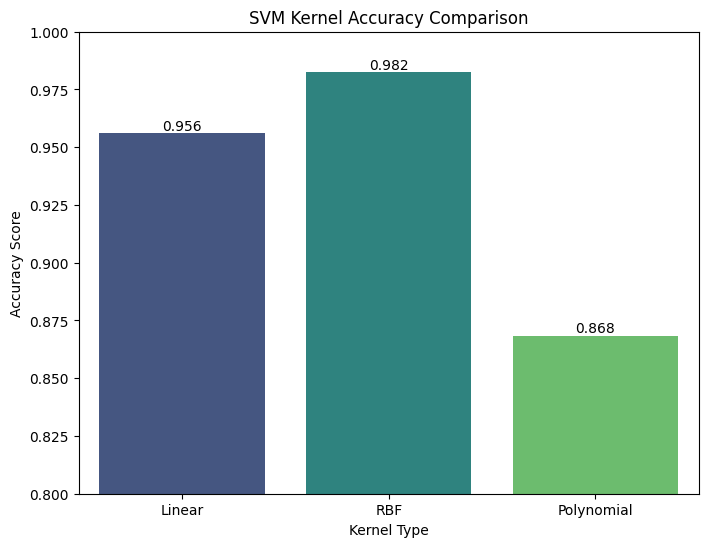

In [66]:
#@title Accuracy Comparison Chart

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate accuracy scores (if not already calculated or stored)
accuracy_linear = accuracy_score(y_test, y_pred_linear)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
accuracy_poly = accuracy_score(y_test, y_pred_poly)

# Create a DataFrame for easy plotting
accuracy_data = pd.DataFrame({
    'Kernel': ['Linear', 'RBF', 'Polynomial'],
    'Accuracy': [accuracy_linear, accuracy_rbf, accuracy_poly]
})

# Plotting the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='Kernel', y='Accuracy', data=accuracy_data, palette='viridis')
plt.title('SVM Kernel Accuracy Comparison')
plt.xlabel('Kernel Type')
plt.ylabel('Accuracy Score')
plt.ylim(0.8, 1.0) # Set y-axis limit to better visualize differences

# Add accuracy values on top of bars
for index, row in accuracy_data.iterrows():
    plt.text(row.name, row.Accuracy, f'{row.Accuracy:.3f}', color='black', ha="center", va='bottom')

plt.show()

## COMPARISON BETWEEEN MODELS EFFICIENCY
When you look at the accuracy scores the RBF kernel did the job. It got an accuracy of about 0.982. The linear kernel got 0.956 and the polynomial kernel got 0.868.

The RBF kernel did better for a reason. The breast cancer dataset is not simple. It is not linear either. The connection between the features is a bit complicated. So you cannot separate the two classes, which're malignant and benign with just a straight line.

This is where the RBF kernel does a job. It can handle these patterns. It does this by changing the data into a dimensional space. In this space it is easier to separate the classes. The linear kernel is not as good because it thinks everything can be split with a line.

The polynomial kernel also tries to find non patterns.. It can be hard to use. It depends on the degree you choose. In this case degree 3 did not work well. This might be because it did not find complicated patterns or it did not work well with the data.

So the RBF kernel was the best here. It balanced being flexible and being accurate. This allowed it to find the patterns in the breast cancer dataset. The RBF kernel did a job, with the breast cancer dataset because it was flexible and accurate.

## Task 5 — Hyperparameter Tuning with GridSearchCV (RBF Kernel)

In [67]:
#@title Hyperparameter Tuning for RBF Kernel SVM

# Defining the parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

# Initializing GridSearchCV with an RBF SVC model
grid_search = GridSearchCV(SVC(kernel='rbf', random_state=42), param_grid, cv=5, verbose=2, n_jobs=-1)

# Fitting GridSearchCV on the scaled training data
grid_search.fit(X_train_scaled, y_train)

# Printing the best parameters and best cross-validation score
print("\n--- GridSearchCV Results ---")
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation score (accuracy):", grid_search.best_score_)

# Getting the best estimator
best_svm_rbf = grid_search.best_estimator_

# Re-evaluating on the test set using the best estimator
y_pred_best_rbf = best_svm_rbf.predict(X_test_scaled)

print("\n--- Evaluation of Best RBF SVM on Test Set ---")
print("Accuracy:", accuracy_score(y_test, y_pred_best_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best_rbf))
print("Classification Report:\n", classification_report(y_test, y_pred_best_rbf))

Fitting 5 folds for each of 16 candidates, totalling 80 fits

--- GridSearchCV Results ---
Best parameters found: {'C': 1, 'gamma': 'scale'}
Best cross-validation score (accuracy): 0.9758241758241759

--- Evaluation of Best RBF SVM on Test Set ---
Accuracy: 0.9824561403508771
Confusion Matrix:
 [[41  2]
 [ 0 71]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

